## **Introduction**

This machine learning project focuses on assisting in the early detection of diabetes by analyzing patient health data such as glucose levels, BMI, age, blood pressure, and insulin levels. The model is trained on labeled medical dataset to identify patterns associated with diabetic and non-diabetic individuals. It helps healthcare professionals make informed decisions.

Our project predicts whether a patient has diabetes or not using machine learning, specifically Logistic Regression.

## **Importing packages**

We start by importing the important packages/libraries essential to create the model such as Pandas (for data manipulation), Numpy (numerical computation), Seaborn and Matplotlib (for data visualization) as well as Scikit-learn (for machine learning).

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report
)
from sklearn.preprocessing import StandardScaler

### **Importing Data**

Here, we have taken a synthetic dataset which simulates real patient data for learning and experimentation purposes.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/diabetes_2000_patients.csv')
df

,PatientID,Age,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Outcome
0,P0001,59,13,141,68,17,8,31.4,0.129,1
1,P0002,72,14,131,56,25,174,27.3,2.252,1
2,P0003,49,8,113,107,51,461,37.5,1.332,1
3,P0004,35,14,130,83,32,306,21.9,1.204,1
4,P0005,63,16,97,100,39,587,19.1,2.162,0
...,...,...,...,...,...,...,...,...,...,...
1995,P1996,57,0,83,117,30,482,29.6,1.932,0
1996,P1997,45,6,85,67,32,206,32.4,0.981,0
1997,P1998,68,16,179,41,45,668,22.6,1.444,1
1998,P1999,21,2,141,82,17,578,38.8,2.100,1


### **Exploratory Data Analysis (EDA)**

EDA includes understanding the dataset using functions like head, shape, and describe, and visualizations like heatmaps and plots to identify patterns and relationships.

In [ ]:
df.head()

,PatientID,Age,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Outcome
0,P0001,59,13,141,68,17,8,31.4,0.129,1
1,P0002,72,14,131,56,25,174,27.3,2.252,1
2,P0003,49,8,113,107,51,461,37.5,1.332,1
3,P0004,35,14,130,83,32,306,21.9,1.204,1
4,P0005,63,16,97,100,39,587,19.1,2.162,0


In [ ]:
df.tail()

,PatientID,Age,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Outcome
1995,P1996,57,0,83,117,30,482,29.6,1.932,0
1996,P1997,45,6,85,67,32,206,32.4,0.981,0
1997,P1998,68,16,179,41,45,668,22.6,1.444,1
1998,P1999,21,2,141,82,17,578,38.8,2.100,1
1999,P2000,73,2,159,47,40,386,41.1,0.114,0


In [ ]:
df.describe()

,Age,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Outcome
count,2000.000000,2000.00000,2000.000000,2000.00000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,51.057500,8.48050,130.360500,81.04500,31.883000,431.94250,31.982100,1.289764,0.653500
std,17.282724,5.17639,40.099233,23.93724,15.942911,249.54183,6.960114,0.698806,0.475974
min,21.000000,0.00000,60.000000,40.00000,5.000000,0.00000,15.000000,0.070000,0.000000
25%,37.000000,4.00000,95.000000,60.00000,18.000000,216.75000,27.100000,0.692000,0.000000
50%,51.000000,8.00000,131.000000,82.00000,31.000000,439.00000,32.000000,1.307000,1.000000
75%,66.000000,13.00000,164.000000,102.00000,46.000000,648.50000,36.925000,1.898000,1.000000
max,80.000000,17.00000,199.000000,121.00000,59.000000,849.00000,52.400000,2.498000,1.000000


In [ ]:
df.columns

Index(['PatientID', 'Age', 'Pregnancies', 'Glucose', 'BloodPressure',
       'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction',
       'Outcome'],
      dtype='object')

In [ ]:
df.shape

(2000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 2000 non-null   object 
 1   Age                       2000 non-null   int64  
 2   Pregnancies               2000 non-null   int64  
 3   Glucose                   2000 non-null   int64  
 4   BloodPressure             2000 non-null   int64  
 5   SkinThickness             2000 non-null   int64  
 6   Insulin                   2000 non-null   int64  
 7   BMI                       2000 non-null   float64
 8   DiabetesPedigreeFunction  2000 non-null   float64
 9   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 156.4+ KB


In [ ]:
df.isnull().sum()

,0
PatientID,0
Age,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Outcome,0


### **Data Preprocessing**

We cleaned the data and removed unnecessary columns. Then we applied feature scaling using StandardScaler so that all values are on the same scale, which improves model performance.

In [ ]:
df = df.drop(columns=["PatientID"])
df

,Age,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Outcome
0,59,13,141,68,17,8,31.4,0.129,1
1,72,14,131,56,25,174,27.3,2.252,1
2,49,8,113,107,51,461,37.5,1.332,1
3,35,14,130,83,32,306,21.9,1.204,1
4,63,16,97,100,39,587,19.1,2.162,0
...,...,...,...,...,...,...,...,...,...
1995,57,0,83,117,30,482,29.6,1.932,0
1996,45,6,85,67,32,206,32.4,0.981,0
1997,68,16,179,41,45,668,22.6,1.444,1
1998,21,2,141,82,17,578,38.8,2.100,1


In [ ]:
df["Outcome_Label"] = df["Outcome"].map({
    0: "No Diabetes",
    1: "Diabetes"
})

In [ ]:
df["Outcome_Label"].value_counts()

,count
Outcome_Label,
Diabetes,1307
No Diabetes,693


### **Data Visualization**

We have visualized our model using heatmap which helps us to know the correlation between numerical features in a model. Here a positive value denotes a perfect correlation whereas a negative value denotes a negative correlation.

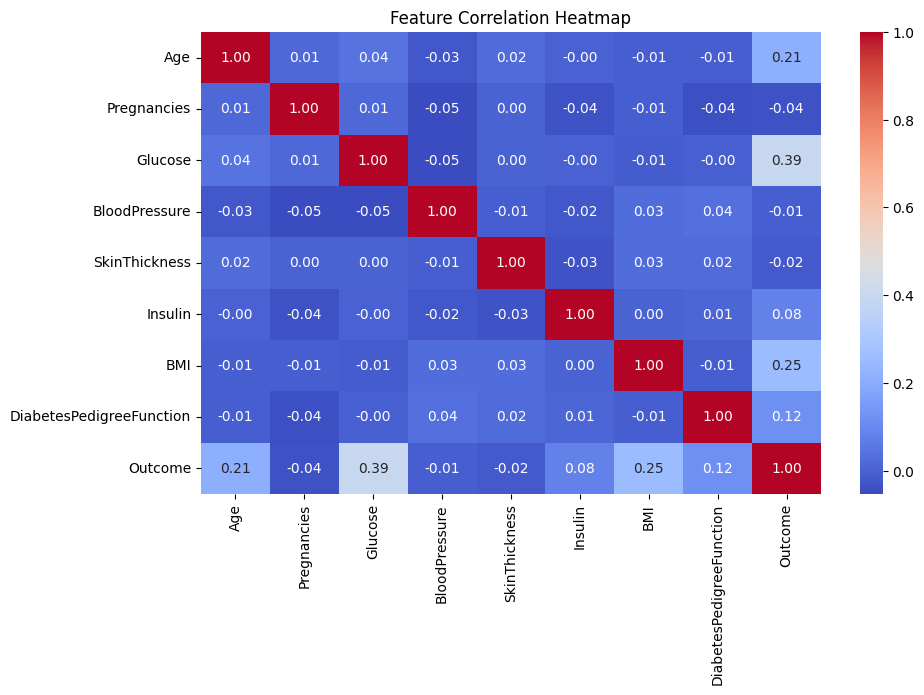

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=["Outcome_Label"]).corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Further, we have used a bar chart to represent the frequency of occurence of diabetic and non-diabetic patients. This is known as 'Count Plot.'

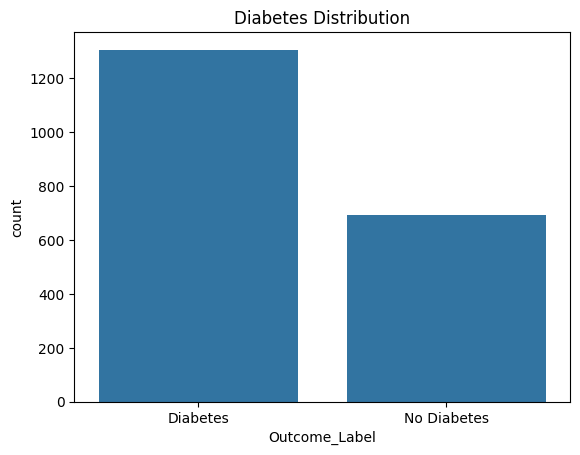

In [ ]:
sns.countplot(x="Outcome_Label", data=df)
plt.title("Diabetes Distribution")
plt.show()

Then, we created a Box Plot which represents the IQR (Inter-Quartile Range) of the data. 50% of the data fits within this range. The middle line between the box is called "median" and the line extending from box is called "whiskers." The points beyond whiskers are the outliers.

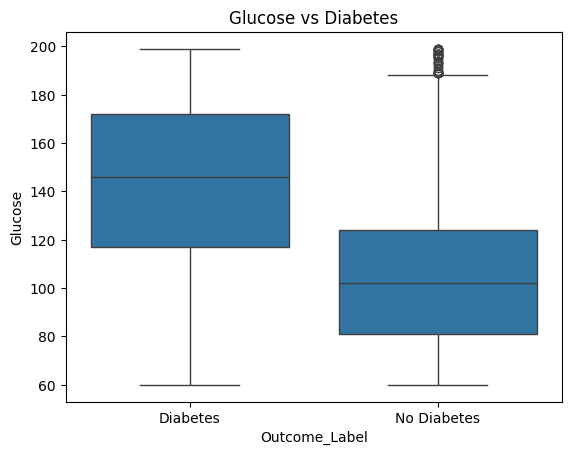

In [ ]:
sns.boxplot(x="Outcome_Label", y="Glucose", data=df)
plt.title("Glucose vs Diabetes")
plt.show()

### **Prepare features and target**

In [ ]:
X = df.drop(columns=["Outcome", "Outcome_Label"])
y = df["Outcome"]

In [ ]:
print("\nFeatures used:", X.columns.tolist())
print("Target: Outcome (0 = Healthy, 1 = Diabetic)")


Features used: ['Age', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
Target: Outcome (0 = Healthy, 1 = Diabetic)


### **Split model into train & test**

We divided the dataset into training and testing sets. 80% data is used to train the model and 20% is used to test its performance.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Training samples: 1600
Testing samples:  400


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### **Train the model using Classification**

We used Logistic Regression, which is a classification algorithm to predict whether the patient is diabetic or not. It calculates the probability of diabetes and classifies based on that probability. After training, the model predicts outcomes on unseen data.

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)

### **Model Evaluation**

We evaluated the model using accuracy, precision, recall, and F1-score. Our model achieved around 76.5% accuracy.

Accuracy denotes total correctly identifying instances among all of the instances. Accuracy can be calculated using following formulas:

𝐴⁢𝐶⁢𝐶=
𝑇𝑝+𝑇𝑁/
𝑇𝑝+𝑇𝑁+𝐹𝑝+𝐹𝑁

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
cm       = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["No Diabetes", "Diabetes"]
))

Accuracy: 0.7650  (76.50%)

Confusion Matrix:
[[ 77  62]
 [ 32 229]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.71      0.55      0.62       139
    Diabetes       0.79      0.88      0.83       261

    accuracy                           0.77       400
   macro avg       0.75      0.72      0.73       400
weighted avg       0.76      0.77      0.76       400



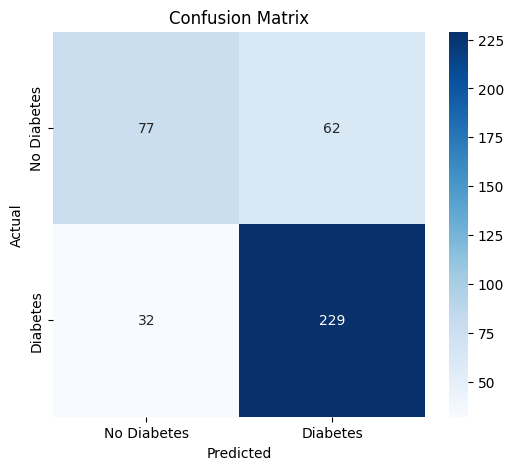

In [ ]:
labels = ["No Diabetes", "Diabetes"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### **Feature Importance**

Feature Importance determines how important each feature is for our dataset by finding the coefficients.

A positive coefficient indicates that as the feature increases, the probability of positive outcome increases.
A negative coefficient indicates that as the feature increases, the probability of positive outcome decreases.

In [ ]:
print("\nModel Coefficients (Feature Importance):")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.3f}")


Model Coefficients (Feature Importance):
Age: 0.584
Pregnancies: -0.137
Glucose: 1.106
BloodPressure: 0.014
SkinThickness: -0.078
Insulin: 0.238
BMI: 0.784
DiabetesPedigreeFunction: 0.330


### **Predict for a new patient**

We also tested the model on a new patient’s data, and it predicts whether the person is diabetic along with probability.

In [ ]:
new_patient = pd.DataFrame([{
    "Age":                        35,
    "Pregnancies":                 2,
    "Glucose":                   138,
    "BloodPressure":              70,
    "SkinThickness":              30,
    "Insulin":                     0,
    "BMI":                      33.6,
    "DiabetesPedigreeFunction": 0.627
}])

new_scaled  = scaler.transform(new_patient)
prediction  = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0][1]

In [ ]:
print(f"Prediction:              {'Diabetic' if prediction == 1 else 'Not Diabetic'}")
print(f"Probability of Diabetes: {probability*100:.1f}%")

Prediction:              Diabetic
Probability of Diabetes: 55.0%
